In [1]:
import xarray as xr
import matplotlib.pyplot as plt
from xgcm import Grid
import numpy as np

In [2]:
def read_data(exp_dir): 
    ds = xr.open_dataset(exp_dir+ 'prog.nc', decode_times=False)
    ds_z = xr.open_dataset(exp_dir+ 'prog_z.nc', decode_times=False)

    return ds, ds_z

In [3]:
os_simple_GM = xr.open_dataset('/scratch/db194/mom6/may2025/MOM6_channel_GM/ocean.stats.nc', decode_times=False)
ds_simple_GM = xr.open_dataset('/scratch/db194/mom6/may2025/MOM6_channel_GM/prog.nc', decode_times=False)
ds_simple_GM_z = xr.open_dataset('/scratch/db194/mom6/may2025/MOM6_channel_GM/prog_z.nc', decode_times=False)

ERROR 1: PROJ: proj_create_from_database: Open of /ext3/miniforge/share/proj failed


In [4]:
os_ANN_GM = xr.open_dataset('/scratch/db194/mom6/may2025/MOM6_channel_GM_ANN/ocean.stats.nc', decode_times=False)
ds_ANN_GM = xr.open_dataset('/scratch/db194/mom6/may2025/MOM6_channel_GM_ANN/prog.nc', decode_times=False)
ds_ANN_GM_z = xr.open_dataset('/scratch/db194/mom6/may2025/MOM6_channel_GM_ANN/prog_z.nc', decode_times=False)

In [5]:
os_ANN_GM_50 = xr.open_dataset('/scratch/db194/mom6/may2025/MOM6_channel_GM_ANN_50km/ocean.stats.nc', decode_times=False)
ds_ANN_GM_50 = xr.open_dataset('/scratch/db194/mom6/may2025/MOM6_channel_GM_ANN_50km/prog.nc', decode_times=False)
ds_ANN_GM_z_50 = xr.open_dataset('/scratch/db194/mom6/may2025/MOM6_channel_GM_ANN_50km/prog_z.nc', decode_times=False)

In [13]:
ds_ANN_GM_50

<xarray.Dataset>
Dimensions:          (xq: 45, yh: 40, zl: 30, Time: 300, xh: 44, yq: 41, zi: 31)
Coordinates:
  * xq               (xq) float64 0.0 0.5 1.0 1.5 2.0 ... 20.5 21.0 21.5 22.0
  * yh               (yh) float64 -49.75 -49.25 -48.75 ... -31.25 -30.75 -30.25
  * zl               (zl) float64 2.5 10.0 22.5 40.0 ... 2.3e+03 2.5e+03 2.8e+03
  * Time             (Time) float64 1.0 2.0 3.0 4.0 ... 297.0 298.0 299.0 300.0
  * xh               (xh) float64 0.25 0.75 1.25 1.75 ... 20.75 21.25 21.75
  * yq               (yq) float64 -50.0 -49.5 -49.0 -48.5 ... -31.0 -30.5 -30.0
  * zi               (zi) float64 0.0 5.0 15.0 30.0 ... 2.4e+03 2.6e+03 3e+03
Data variables: (12/25)
    u                (Time, zl, yh, xq) float32 ...
    v                (Time, zl, yq, xh) float32 ...
    h                (Time, zl, yh, xh) float64 ...
    ssh              (Time, yh, xh) float32 ...
    neutral_slope_x  (Time, zi, yh, xq) float64 ...
    neutral_slope_y  (Time, zi, yq, xh) float64 ...
    ...               ...
    dhbardy          (Time, zl, yh, xh) float64 ...
    Fx               (Time, zl, yh, xh) float64 ...
    Fy               (Time, zl, yh, xh) float64 ...
    uhTrANN          (Time, zl, yh, xq) float64 ...
    vhTrANN          (Time, zl, yq, xh) float64 ...
    h_mask           (Time, zl, yh, xh) float64 ...
Attributes:
    filename:   prog.nc
    title:      MOM Experiment
    grid_type:  regular
    grid_tile:  N/A

In [6]:
os = xr.open_dataset('/scratch/db194/mom6/may2025/MOM6_channel/ocean.stats.nc', decode_times=False)
ds = xr.open_dataset('/scratch/db194/mom6/may2025/MOM6_channel/prog.nc', decode_times=False)
ds_z = xr.open_dataset('/scratch/db194/mom6/may2025/MOM6_channel/prog_z.nc', decode_times=False)

In [7]:
grid = Grid(ds_ANN_GM, periodic='X')

In [8]:
coords = {'X': {'center': 'xh', 'outer': 'xq'},
                'Y': {'center': 'yh', 'outer': 'yq'},
                'Z': {'center': 'zl', 'outer': 'zi'} }
    
grid = Grid(ds_ANN_GM, coords=coords, periodic=['X'])

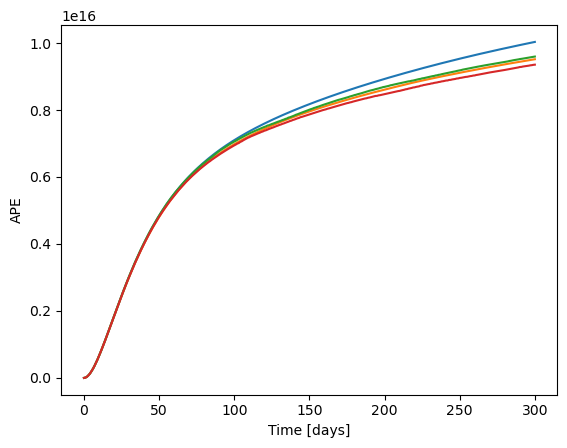

In [9]:
os.APE.sum('Interface').plot()
os_simple_GM.APE.sum('Interface').plot()
os_ANN_GM.APE.sum('Interface').plot()
os_ANN_GM_50.APE.sum('Interface').plot()

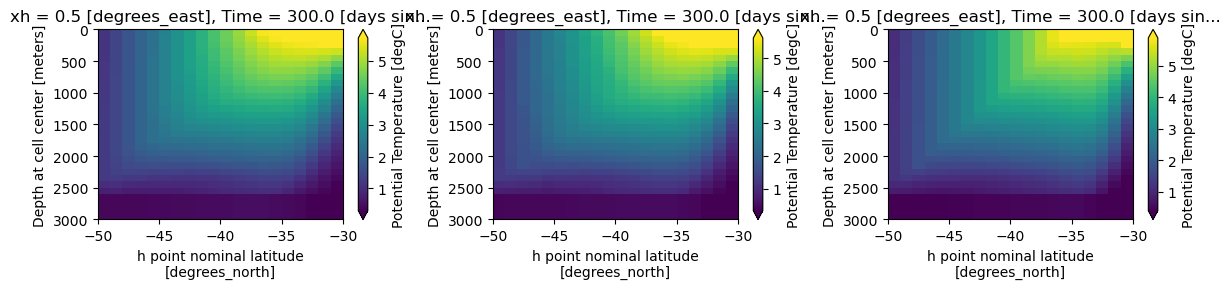

In [11]:
plt.figure(figsize=(12,3))

idT = -1

plt.subplot(131)
ds_simple_GM_z.temp.isel(Time=idT, xh=0).plot(robust=True)
plt.gca().invert_yaxis()

plt.subplot(132)
ds_ANN_GM_z.temp.isel(Time=idT, xh=0).plot(robust=True)
plt.gca().invert_yaxis()

plt.subplot(133)
ds_z.temp.isel(Time=idT, xh=0).plot(robust=True)
plt.gca().invert_yaxis()

plt.tight_layout()


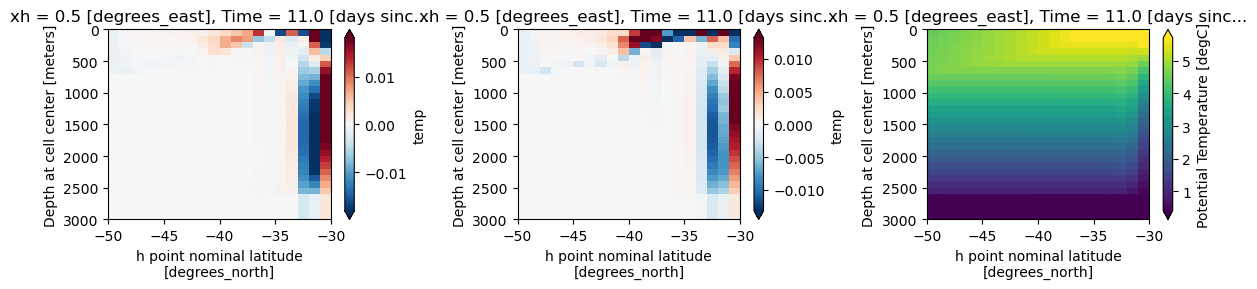

In [40]:
plt.figure(figsize=(12,3))

idT = 10

plt.subplot(131)
(ds_simple_GM_z.temp - ds_z.temp).isel(Time=idT, xh=0).plot(robust=True)
plt.gca().invert_yaxis()

plt.subplot(132)
(ds_ANN_GM_z.temp - ds_z.temp).isel(Time=idT, xh=0).plot(robust=True)
plt.gca().invert_yaxis()

plt.subplot(133)
ds_z.temp.isel(Time=idT, xh=0).plot(robust=True)
plt.gca().invert_yaxis()

plt.tight_layout()


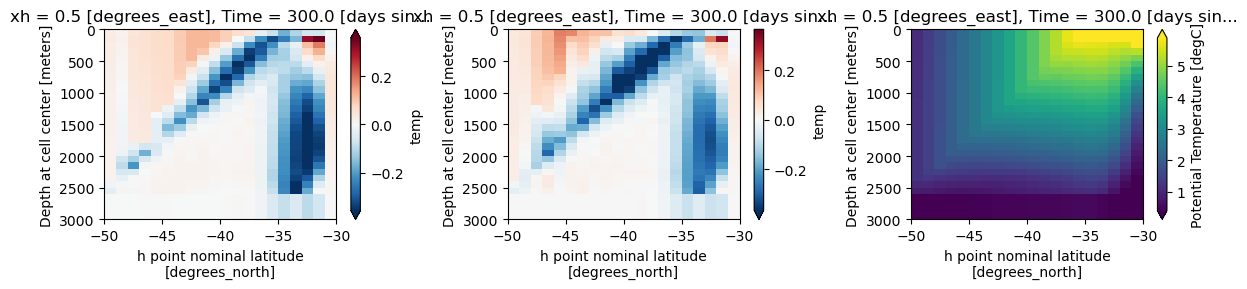

In [41]:
plt.figure(figsize=(12,3))

idT = -1

plt.subplot(131)
(ds_simple_GM_z.temp - ds_z.temp).isel(Time=idT, xh=0).plot(robust=True)
plt.gca().invert_yaxis()

plt.subplot(132)
(ds_ANN_GM_z.temp - ds_z.temp).isel(Time=idT, xh=0).plot(robust=True)
plt.gca().invert_yaxis()

plt.subplot(133)
ds_z.temp.isel(Time=idT, xh=0).plot(robust=True)
plt.gca().invert_yaxis()

plt.tight_layout()


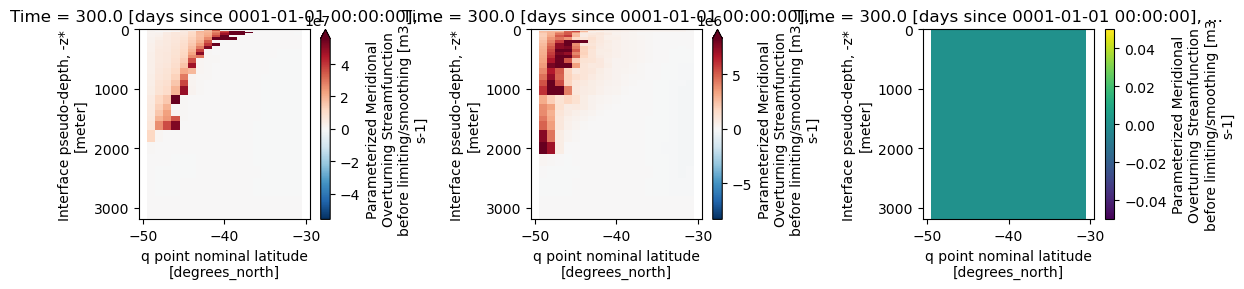

In [42]:
plt.figure(figsize=(12,3))

idT = -1

plt.subplot(131)
ds_simple_GM.GM_sfn_unlim_y.isel(Time=idT, xh=0).plot(robust=True)
plt.gca().invert_yaxis()

plt.subplot(132)
ds_ANN_GM.ANN_sfn_unlim_y.isel(Time=idT, xh=0).plot(robust=True)
plt.gca().invert_yaxis()

plt.subplot(133)
ds.GM_sfn_unlim_y.isel(Time=idT, xh=0).plot(robust=True)
plt.gca().invert_yaxis()
#plt.ylim(2000,0)

plt.tight_layout()


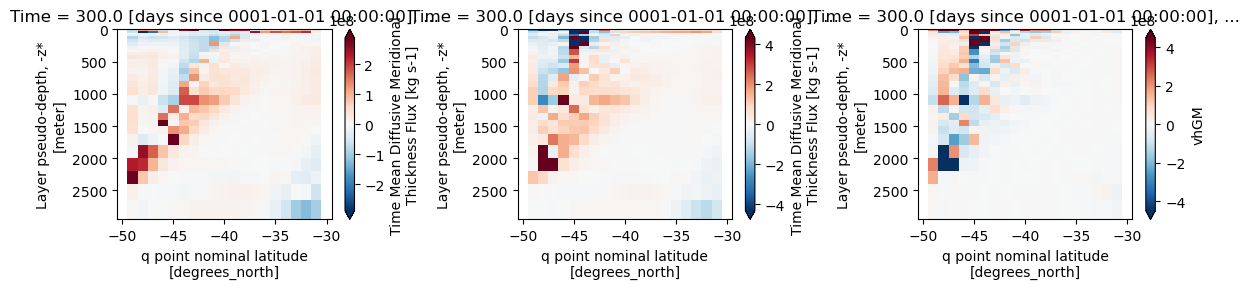

In [43]:
plt.figure(figsize=(12,3))

idT = -1

plt.subplot(131)
ds_simple_GM.vhGM.isel(Time=idT, xh=0).plot(robust=True)
plt.gca().invert_yaxis()
#plt.ylim(2000,0)

plt.subplot(132)
ds_ANN_GM.vhGM.isel(Time=idT, xh=0).plot(robust=True)
plt.gca().invert_yaxis()
#plt.ylim(2000,0)

plt.subplot(133)
(ds_simple_GM.vhGM - ds_ANN_GM.vhGM).isel(Time=idT, xh=0).plot(robust=True)
plt.gca().invert_yaxis()
#plt.ylim(2000,0)

plt.tight_layout()


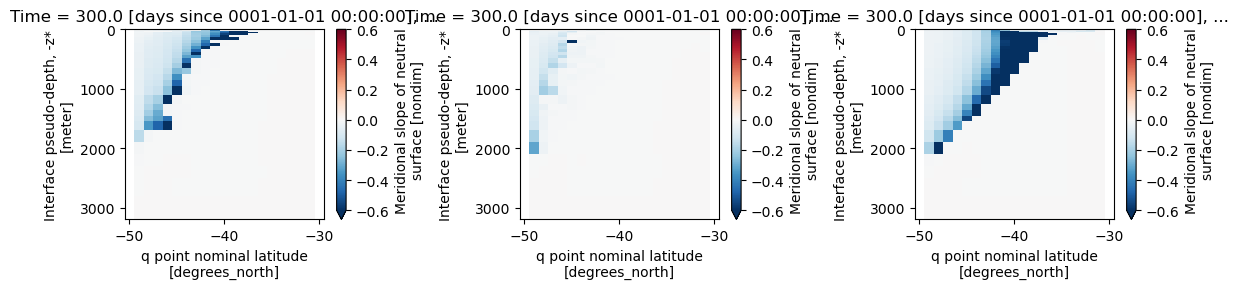

In [44]:
plt.figure(figsize=(12,3))

idT = -1

plt.subplot(131)
ds_simple_GM.neutral_slope_y.isel(Time=idT, xh=0).plot(vmin=-0.6)
plt.gca().invert_yaxis()
#plt.ylim(300,0)

plt.subplot(132)
ds_ANN_GM.ANN_slope_y.isel(Time=idT, xh=0).plot(vmin=-0.6)
plt.gca().invert_yaxis()

plt.subplot(133)
ds.neutral_slope_y.isel(Time=idT, xh=0).plot(vmin=-0.6)
plt.gca().invert_yaxis()
#plt.ylim(300,0)


#plt.ylim(300,0)

plt.tight_layout()

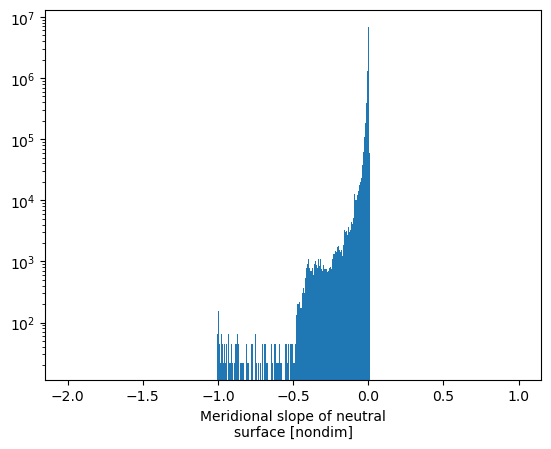

In [80]:
ds_ANN_GM.ANN_slope_y.plot.hist(bins=np.linspace(-2,1,501))
plt.yscale('log')

In [59]:
ds_ANN_GM.ANN_slope_y.min(), ds_simple_GM.neutral_slope_y.min()

(<xarray.DataArray 'ANN_slope_y' ()>
 array(-0.99985681),
 <xarray.DataArray 'neutral_slope_y' ()>
 array(-0.99901558))

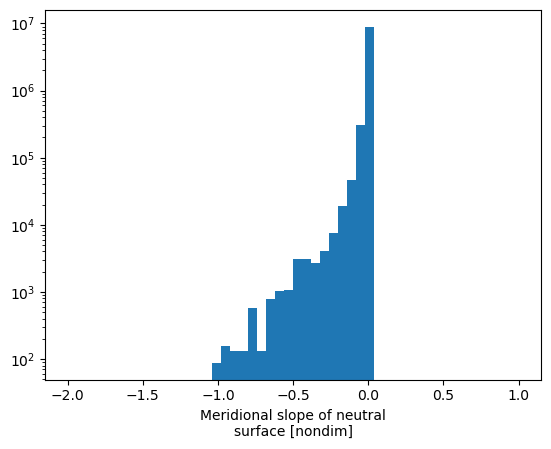

In [117]:
ds_ANN_GM.neutral_slope_y.plot.hist(bins=np.linspace(-2,1,51))
plt.yscale('log')

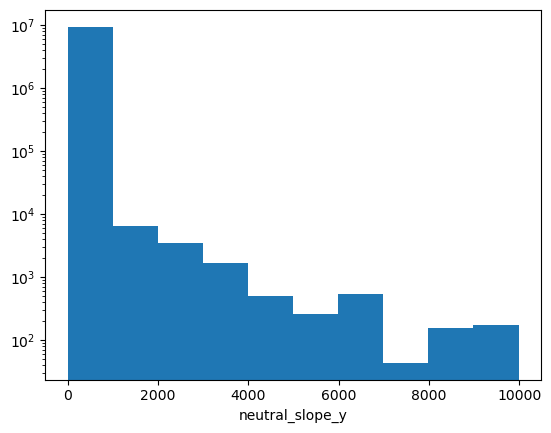

In [120]:
(ds_ANN_GM.neutral_slope_y**2 / 1e-4).plot.hist()
plt.yscale('log')

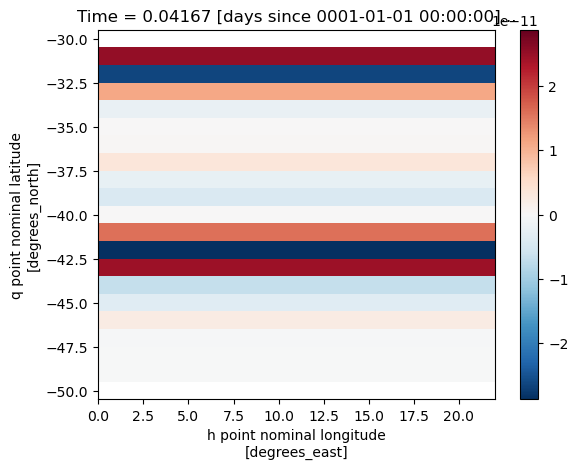

In [132]:
idT = 0
(ds_simple_GM.neutral_slope_y - ds_ANN_GM.ANN_slope_y).isel(Time=idT, zi=10).plot()

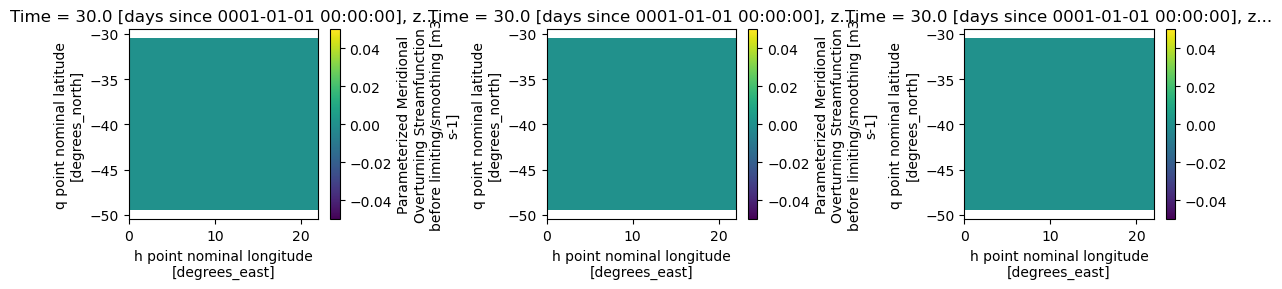

In [73]:
plt.figure(figsize=(12,3))


idT = -1

plt.subplot(131)
ds_simple_GM.GM_sfn_unlim_y.isel(Time=idT, zi=0).plot(robust=True)

plt.subplot(132)
ds_ANN_GM.ANN_sfn_unlim_y.isel(Time=idT, zi=0).plot(robust=True)

plt.subplot(133)
(ds_simple_GM.GM_sfn_unlim_y - ds_ANN_GM.ANN_sfn_unlim_y).isel(Time=idT, zi=0).plot()

plt.tight_layout()

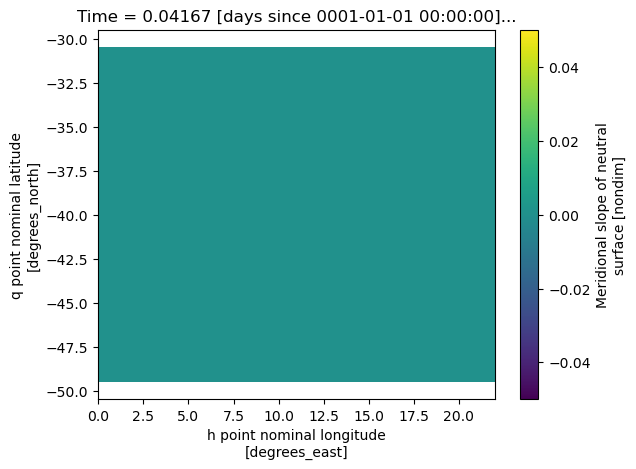

In [24]:
ds_ANN_GM.ANN_slope_y.isel(Time=idT, zi=0).plot()

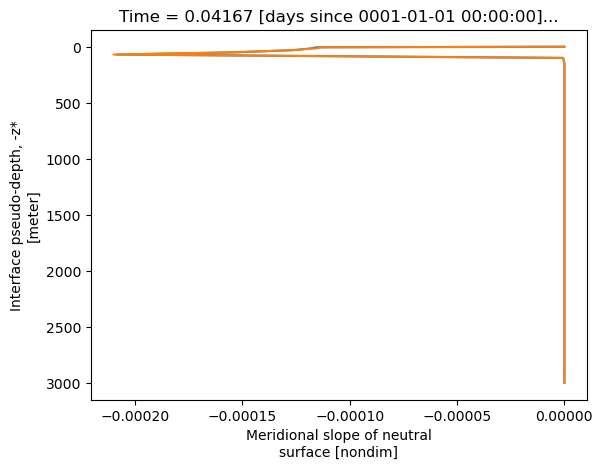

In [14]:
ds_simple_GM.neutral_slope_y.isel(Time=idT, xh=0, yq=10).plot(y='zi')
ds_ANN_GM.ANN_slope_y.isel(Time=idT, xh=0, yq=10).plot(y='zi')
plt.gca().invert_yaxis()

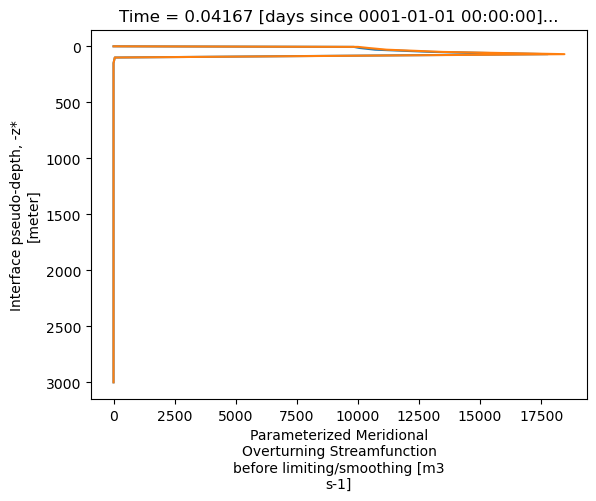

In [15]:
ds_simple_GM.GM_sfn_unlim_y.isel(Time=idT, xh=0, yq=10).plot(y='zi')
ds_ANN_GM.ANN_sfn_unlim_y.isel(Time=idT, xh=0, yq=10).plot(y='zi')
plt.gca().invert_yaxis()

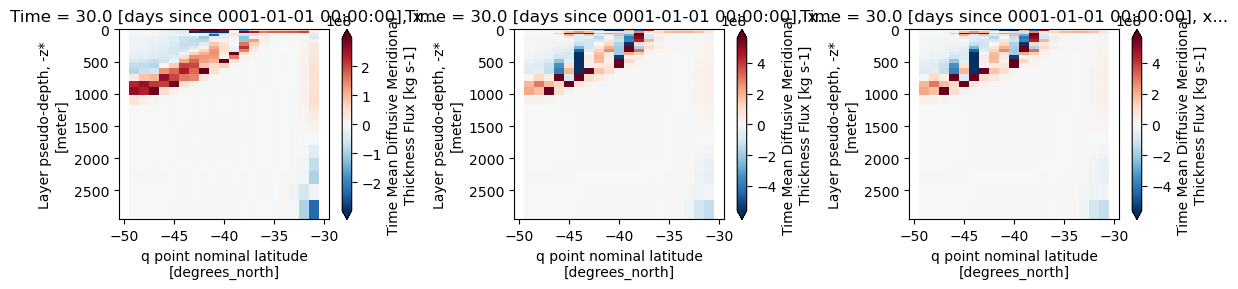

In [63]:
plt.figure(figsize=(12,3))

idT = -1

plt.subplot(131)
ds_simple_GM.vhGM.isel(Time=idT, xh=0).plot(robust=True)
plt.gca().invert_yaxis()

plt.subplot(132)
ds_ANN_GM.vhGM.isel(Time=idT, xh=0).plot(robust=True)
plt.gca().invert_yaxis()

plt.subplot(133)
ds_ANN_GM.vhGM.isel(Time=idT, xh=0).plot(robust=True)
plt.gca().invert_yaxis()

plt.tight_layout()

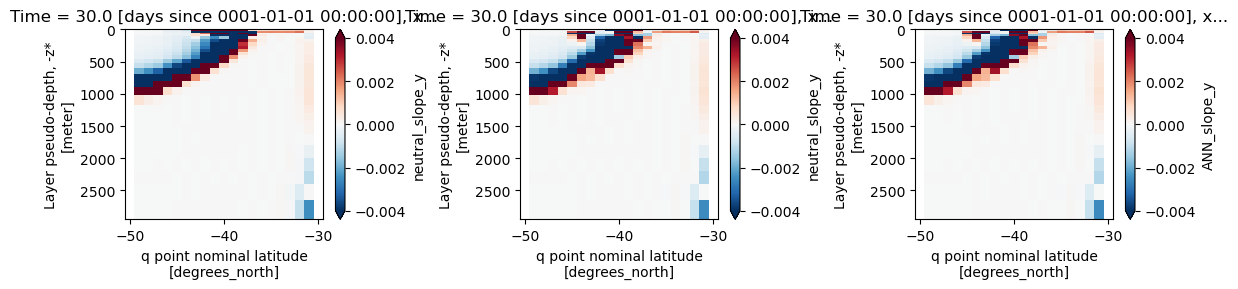

In [55]:
plt.figure(figsize=(12,3))

idT = -1 

plt.subplot(131)
grid.diff(ds_simple_GM.neutral_slope_y, 'Z', boundary='extend').isel(Time=idT, xh=0).plot(vmin=-4e-3)
plt.gca().invert_yaxis()

plt.subplot(132)
grid.diff(ds_ANN_GM.neutral_slope_y, 'Z', boundary='extend').isel(Time=idT, xh=0).plot(vmin=-4e-3)
plt.gca().invert_yaxis()

plt.subplot(133)
grid.diff(ds_ANN_GM.ANN_slope_y, 'Z', boundary='extend').isel(Time=idT, xh=0).plot(vmin=-4e-3)
plt.gca().invert_yaxis()

plt.tight_layout()

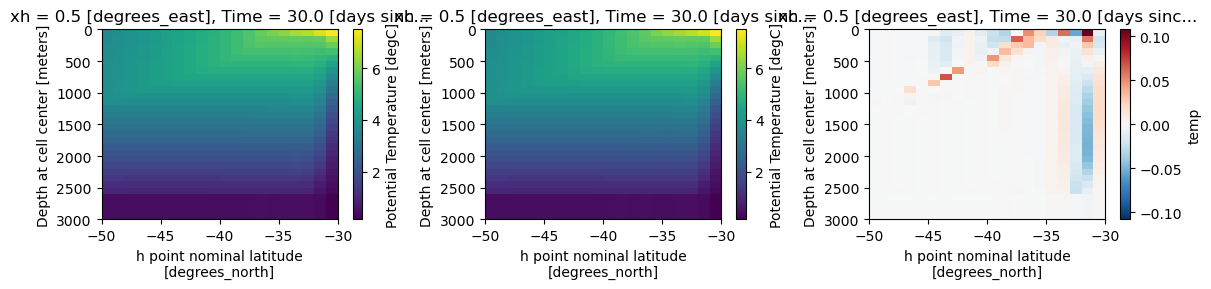

In [66]:
plt.figure(figsize=(12,3))

idT = -1 
plt.subplot(131)
ds_simple_GM_z.temp.isel(Time=idT, xh=0).plot()
plt.gca().invert_yaxis()

plt.subplot(132)
ds_ANN_GM_z.temp.isel(Time=idT, xh=0).plot()
plt.gca().invert_yaxis()

plt.subplot(133)
(ds_simple_GM_z.temp - ds_ANN_GM_z.temp).isel(Time=idT, xh=0).plot()
plt.gca().invert_yaxis()

plt.tight_layout()

In [17]:
plt.figure(figsize=(8,3))

idT = -1 
plt.subplot(121)
ds_simple_GM_z.temp.isel(Time=idT, xh=0).plot()
plt.gca().invert_yaxis()

plt.subplot(122)
ds_ANN_GM_z.temp.isel(Time=idT, xh=0).plot()
plt.gca().invert_yaxis()

plt.tight_layout()

<xarray.Dataset>
Dimensions:  (xh: 22, yh: 20, z_l: 30, z_i: 31, Time: 10, xq: 23, yq: 21)
Coordinates:
  * xh       (xh) float64 0.5 1.5 2.5 3.5 4.5 5.5 ... 17.5 18.5 19.5 20.5 21.5
  * yh       (yh) float64 -49.5 -48.5 -47.5 -46.5 ... -33.5 -32.5 -31.5 -30.5
  * z_l      (z_l) float64 50.0 150.0 250.0 350.0 ... 2.75e+03 2.85e+03 2.95e+03
  * z_i      (z_i) float64 0.0 100.0 200.0 300.0 ... 2.8e+03 2.9e+03 3e+03
  * Time     (Time) float64 1.0 2.0 3.0 4.0 5.0 6.0 7.0 8.0 9.0 10.0
  * xq       (xq) float64 0.0 1.0 2.0 3.0 4.0 5.0 ... 18.0 19.0 20.0 21.0 22.0
  * yq       (yq) float64 -50.0 -49.0 -48.0 -47.0 ... -33.0 -32.0 -31.0 -30.0
Data variables:
    temp     (Time, z_l, yh, xh) float32 ...
    umo      (Time, z_l, yh, xq) float32 ...
    vmo      (Time, z_l, yq, xh) float32 ...
    u        (Time, z_l, yh, xq) float32 ...
    v        (Time, z_l, yq, xh) float32 ...
    h        (Time, z_l, yh, xh) float64 ...
Attributes:
    filename:   prog_z.nc
    title:      MOM Experiment
    grid_type:  regular
    grid_tile:  N/A

AttributeError: 'Dataset' object has no attribute 'dhdy'

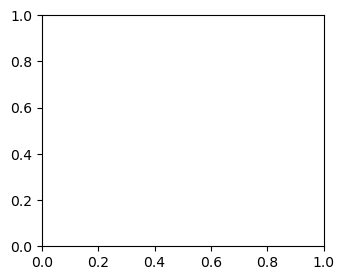

In [94]:
plt.figure(figsize=(8,3))

plt.subplot(121)
ds_simple_GM.dhdy.isel(Time=-2, xh=0).plot(vmin=-4e-3)

plt.subplot(122)
ds_ANN_GM.dhdy.isel(Time=-2, xh=0).plot(vmin=-4e-3)

plt.tight_layout()

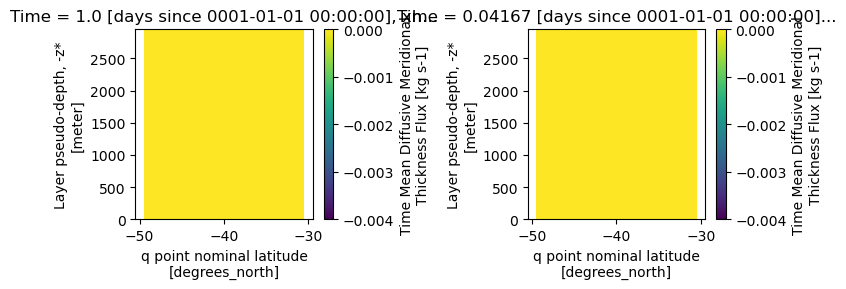

In [78]:
plt.figure(figsize=(8,3))

plt.subplot(121)
ds_simple_GM.vhGM.isel(Time=0, xh=0).plot(vmin=-4e-3)

plt.subplot(122)
ds_ANN_GM.vhGM.isel(Time=0, xh=0).plot(vmin=-4e-3)

plt.tight_layout()

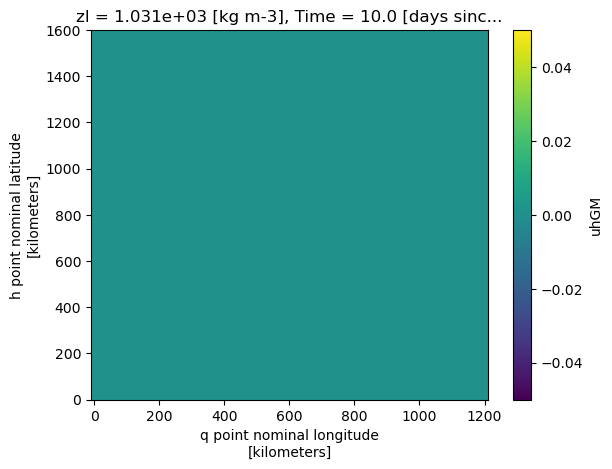

In [46]:
(ds_ANN_GM.uhGM - ds_ANN_GM_new.uhGM).isel(Time=-1, zl=0).plot()